# Top level imports

In [1]:
# Imports
import os
from pathlib import Path
from urllib.parse import urlparse

from fastai.vision.all import *
from fastai.vision.core import *

from PIL import ImageFilter, Image
import numpy as np

import ipyplot

from ipynb.fs.full.Deink_00_Utils import *
from ipynb.fs.full.Deink_00_Utils import _get_sil_y 

Fastai Version: 2.7.12
Image Size: (480, 360)
Clean: True
Batch Size: 4


# Set up top level variables

In [2]:
# Where we should save our in-process model
callback_saved_model = Path("./callback_saved_model")
every_epoch=10
print(f"Temp model saving in {callback_saved_model.parent.resolve()} / {os.path.basename(callback_saved_model)}")

# Control for the number of epocs to run
# epocs = 50
epocs = 10
start_epoch=0
print(f"Traing {epocs} epocs, starting on {start_epoch}")

Temp model saving in /home/jovyan/work/kozobot/deinked / callback_saved_model
Traing 10 epocs, starting on 0


# Pre-Trained Generator

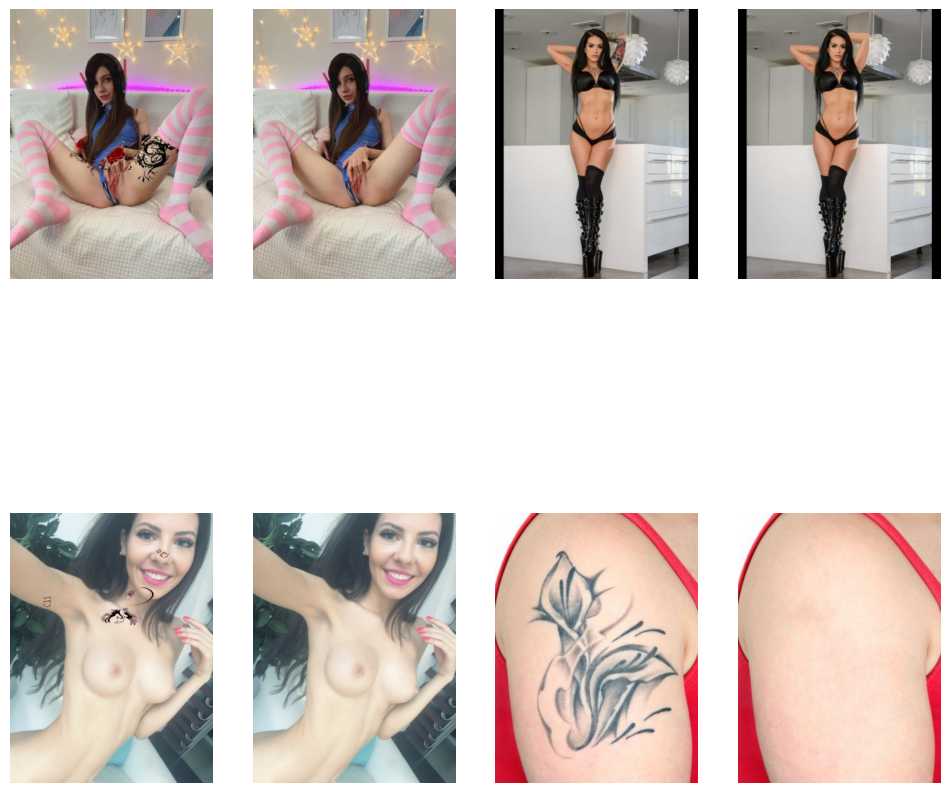

In [3]:
# Load our training data
dls_gen = get_dls(batch_size, image_size) 
dls_gen.show_batch(max_n=4, figsize=(12,12))

In [4]:
# For our backbone
#bbone = resnet34  
#bbone = xresnet34_deeper # clear images slightly faded tatts about 7 sec per run
#bbone = resnet50 
bbone = resnet18 
#bbone = squeezenet1_0 # blue pixelated; about 4 sec per run
#bbone = densenet121 # ran out of mem
#bbone = vgg16_bn # purple pixelated; about 5 sec per run
#bbone = vgg19_bn # blurry images with faded tatts; about 5 sec per run
#bbone = alexnet # pink blocks then blank; about 4 sec per run
def create_gen_learner():
    basename = os.path.basename(callback_saved_model)
    fname = callback_saved_model.parent.resolve()
    
    #cnn_learner??
    learner = unet_learner(dls_gen, bbone, 
                           path=fname,
                           loss_func=loss_gen,
                           blur=True, 
                           norm_type=NormType.Weight,
                           self_attention=True,
                           y_range=y_range,
                           cbs=[
                               # Set things up so that we can resume a crashed training session
                               SaveModelCallback(with_opt=True, fname=basename, every_epoch=every_epoch)
                           ]) 
    
    # See if we need to restore the existing model    
    model_path = Path(f'{fname}/models/{basename}_{start_epoch}.pth')
    if model_path.exists() and start_epoch > 0:
        print(f"WARNING: Resuming existing model training from {model_path} at epoch {start_epoch}")
        learner.load(f'{basename}_{start_epoch}')
        
    return learner

In [5]:
# Let's create our learner
learn_gen = create_gen_learner()

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Do the Learning

SuggestedLRs(valley=0.00020892961765639484)

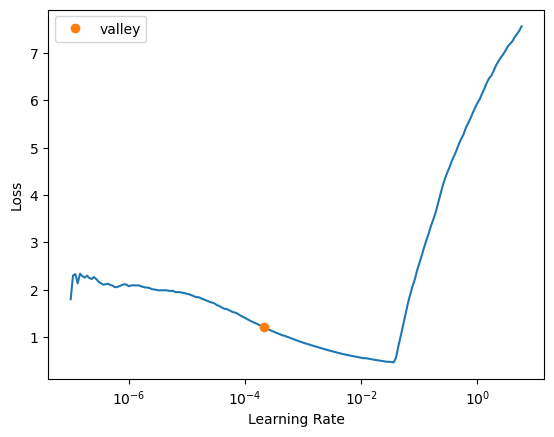

In [6]:
#Plot the loss versus the learning rates. We're interested in finding a good order of magnitude of learning rate, so we plot with a log scale.
learn_gen.lr_find(stop_div=False, num_it=200)
#learn_gen.recorder.plot()

In [7]:
lr_max=0.0003630780556704849

epoch,train_loss,valid_loss,time
0,0.541129,0.101976,00:06
1,0.242065,0.072439,00:06
2,0.138011,0.057814,00:06
3,0.094680,0.066417,00:06
4,0.076107,0.057054,00:06
5,0.066213,0.048486,00:06
6,0.058480,0.039081,00:06
7,0.052415,0.033835,00:06
8,0.044833,0.031474,00:06
9,0.041432,0.030501,00:06


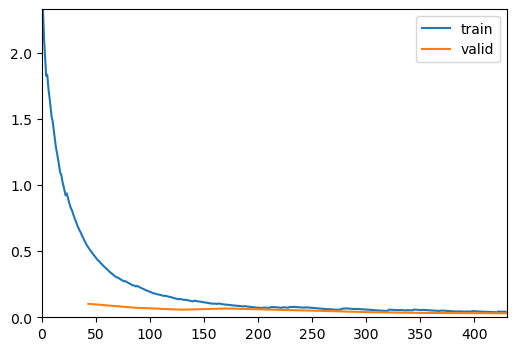

In [8]:
# What callbacks do we want
cbs = []
csv_append = True
if (start_epoch == 0):
    cbs.append(ShowGraphCallback())
    csv_append = False # overwrite whatever is there since we are starting at the beginning
    
# Add a logger to write to csv
cbs.append(CSVLogger(fname=f'deink-{bbone.__name__}-epocs{epocs}_history.csv', append=csv_append))

# Do the learning
learn_gen.fit_one_cycle(epocs,
                        # pct_start=0.3,
                        # wd=wd,
                        # lr_max=lr_max,
                        start_epoch=start_epoch,
                        cbs=cbs
                       )

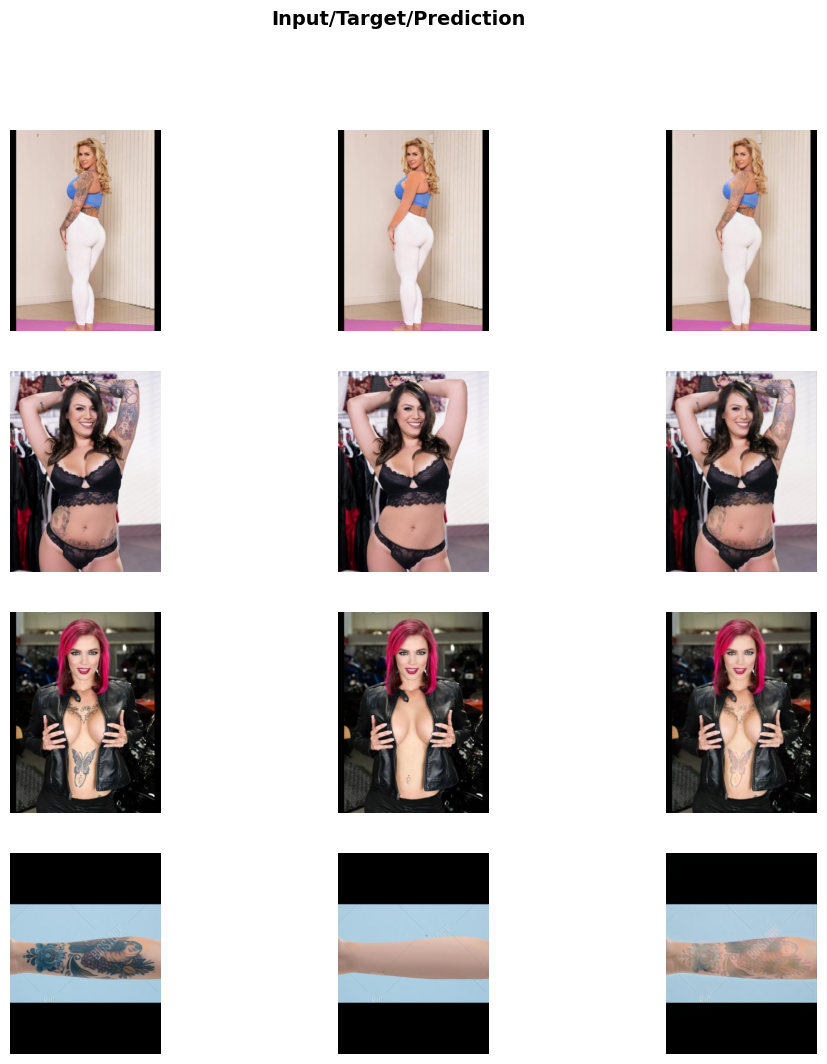

In [9]:
learn_gen.show_results(max_n=4, figsize=(12,12))

# Export the Model

In [10]:
#save the model
deinked_gen_model_file = f'./deinked-{bbone.__name__}-epocs{epocs}.pkl'
learn_gen.export(deinked_gen_model_file)
print(f'Storing model {deinked_gen_model_file}')

%store deinked_gen_model_file

Storing model ./deinked-resnet18-epocs10.pkl
Stored 'deinked_gen_model_file' (str)


# Quick test run

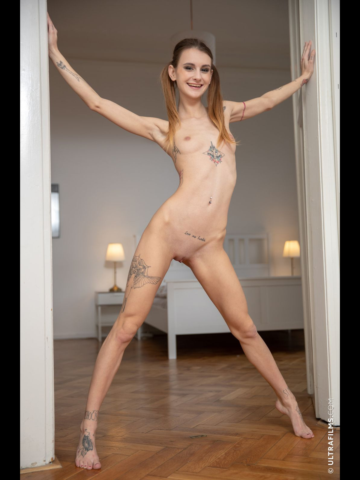

In [11]:
# Load a test file
img_fast_raw = PILImage.create("./data/deinked/test/0010-15.jpg")

# resize = Resize(image_size, 
#                  resamples=(Image.BILINEAR, Image.NEAREST),
#                  method=ResizeMethod.Pad,
#                  pad_mode=PadMode.Zeros)

img_fast = resize(img_fast_raw, split_idx=1).convert("RGB")
display(img_fast)

In [12]:
# Run our prediction
tensor_image, img_hr_tensor_base, preds_tensor_base = learn_gen.predict(img_fast)

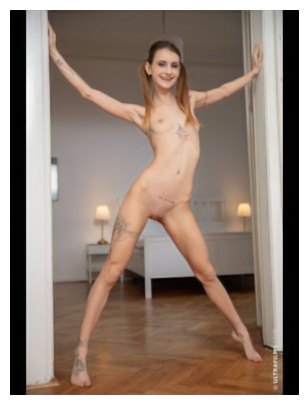

In [13]:
# Show our results
pil_image = PILImage.create(tensor_image)
pil_image.show()
pil_image.save(f"deink-{bbone.__name__}-epocs{epocs}_0010-15.jpg")